In [20]:
import glob
import json
import pandas as pd
import numpy as np
from scipy import stats

from scipy.stats import wilcoxon, pearsonr, zscore
from statsmodels.stats.multitest import multipletests

import seaborn as sns
import matplotlib.pyplot as plt

##### Loading data functions

In [21]:
def Dillion_ratings(): 
    return pd.concat([pd.read_csv('../stimuli/Dillion_et_al_2023.csv',)])["Human rating"].tolist()

def moralvalue68_ratings(filepath='../stimuli/moralgrammar68_human_ratings.json'):
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            data.append(json.loads(line))
    
    df = pd.DataFrame(data)

    return df['morality_rating'], df['syntax_rating']

def moralvalue68_economic_ratings(filepath='../stimuli/MoralEconomic68.csv'):
    ratings = pd.read_csv(filepath)
    ratings['log_price'] = np.log10(ratings['price'])
    return ratings['log_price'].to_list()

def animals_size_ratings():
    ratings = pd.read_excel('../stimuli/Grand_et_al/grand_animals_size.xlsx')
    return ratings.iloc[:, :1].assign(mean=ratings.iloc[:, 1:].mean(axis=1))

def names_age_ratings():
    ratings = pd.read_csv('../stimuli/Grand_et_al/grand_names_age.csv')
    return ratings.iloc[:, :1].assign(mean=ratings.iloc[:, 1:].mean(axis=1))

def states_temperature_ratings():
    ratings = pd.read_csv('../stimuli/Grand_et_al/grand_states_temperature.csv')
    return ratings.iloc[:, :1].assign(mean=ratings.iloc[:, 1:].mean(axis=1))

def weather_wetness_ratings():
    ratings = pd.read_csv('../stimuli/Grand_et_al/grand_weather_wetness.csv')
    return ratings.iloc[:, :1].assign(mean=ratings.iloc[:, 1:].mean(axis=1))

def load_files(file_path, evaluation=None, layers=28, subsample=None):
    def read_first_file(pattern, reader):
        files = glob.glob(pattern)
        if files:
            return reader(files[0])
        return None

    intervention_values = {}
    raw_scores_data = []

    results_df = read_first_file(f'{file_path}/layer_results_*.csv', pd.read_csv)

    baseline_values = read_first_file(f'{file_path}/baseline_values_*.json',
                                      lambda f: json.load(open(f, 'r')))
    if baseline_values:
        intervention_values['baseline'] = baseline_values

    for i in range(1, layers):
        layer_values = read_first_file(f'{file_path}/layer_{i}_values_*.json',
                                       lambda f: json.load(open(f, 'r')))
        if layer_values:
            intervention_values[f'layer_{i}'] = layer_values

    evaluation_ratings = {
        'Dillion': Dillion_ratings(),
        'animals_size': animals_size_ratings()['mean'],
        'moralvalue68_grammar': moralvalue68_ratings()[1],
        'moralvalue68_morality': moralvalue68_ratings()[0],
        'moralvalue68_economic': moralvalue68_economic_ratings(),
        'names_age': names_age_ratings()['mean'],
        'states_temperature': states_temperature_ratings()['mean'],
        'weather_wetness': weather_wetness_ratings()['mean'],
    }

    rating_ranges = {
        'Dillion': (-4, 4),
        'moralvalue68_grammar': (-10, 10),
        'moralvalue68_morality': (-10, 10),
        'moralvalue68_economic': (-10, 10),
        'animals_size': (0, 100),
        'names_age': (0, 100),
        'states_temperature': (0, 100),
        'weather_wetness': (0, 100),
    }

    if evaluation in evaluation_ratings:
        ratings = evaluation_ratings[evaluation]

    for key, values in intervention_values.items():
        for idx, value in enumerate(values):
            row_data = {'index': idx, 'layer': key, 'value': value}
            if evaluation in evaluation_ratings and idx < len(ratings):
                rating_value = ratings[idx]
                row_data['rating'] = rating_value

            raw_scores_data.append(row_data)

    corr_df = pd.DataFrame(index=intervention_values.keys(), columns=['correlation'])

    if evaluation in evaluation_ratings:
        ratings = np.array(pd.to_numeric(evaluation_ratings[evaluation], errors='coerce'))

        for key in intervention_values.keys():
            values = np.array(pd.to_numeric(intervention_values[key], errors='coerce'))

            min_val, max_val = rating_ranges[evaluation]
            valid_range_mask = (values >= min_val) & (values <= max_val) & ~np.isnan(values)
            values_filtered = values[valid_range_mask]
            ratings_filtered = ratings[valid_range_mask]

            if subsample is not None:
                indices = np.random.choice(len(values_filtered), size=min(subsample, len(values_filtered)), replace=True)
                values_sampled = values_filtered[indices]
                ratings_sampled = ratings_filtered[indices]
            elif key == 'baseline' or evaluation == 'Dillion':
                values_sampled = values_filtered
                ratings_sampled = ratings_filtered
            else:
                if len(values_filtered) > 464:
                    indices = np.random.choice(len(values_filtered), size=464, replace=False)
                    values_sampled = values_filtered[indices]
                    ratings_sampled = ratings_filtered[indices]
                else:
                    values_sampled = values_filtered
                    ratings_sampled = ratings_filtered

            if evaluation != 'Dillion' and len(values_sampled) > 1:
                values_sampled = zscore(values_sampled)

            if len(values_sampled) > 1:
                correlation, _ = pearsonr(values_sampled, ratings_sampled)
            else:
                correlation = np.nan

            corr_df.loc[key, 'correlation'] = correlation

    raw_scores_df = pd.DataFrame(raw_scores_data)
    return results_df, corr_df, raw_scores_df

def load_multiple_files(file_paths, evaluation=None, layers=28, subsample=None):
    all_results_df, all_corr_dfs, all_scores_dfs = [], [], []

    if subsample is not None:
        if len(file_paths) == 0:
            return pd.DataFrame(), pd.DataFrame(), pd.DataFrame()

        file_path = file_paths[0]
        for i in range(100):
            try:
                results_df, corr_df, raw_scores_df = load_files(file_path, evaluation, layers, subsample=subsample)
                corr_df['file_path'] = f"{file_path}_subsample_{i}"
                all_corr_dfs.append(corr_df)
                results_df['file_path'] = f"{file_path}_subsample_{i}"
                all_results_df.append(results_df)
                raw_scores_df['source'] = f"{file_path}_subsample_{i}"
                all_scores_dfs.append(raw_scores_df)
            except Exception as e:
                print(f"{e}")
    else:
        for file_path in file_paths:
            try:
                results_df, corr_df, raw_scores_df = load_files(file_path, evaluation, layers)
                corr_df['file_path'] = file_path
                all_corr_dfs.append(corr_df)
                results_df['file_path'] = file_path
                all_results_df.append(results_df)
                raw_scores_df['source'] = file_path
                all_scores_dfs.append(raw_scores_df)
            except Exception as e:
                print(f"{e}")

    all_corr_dfs = pd.concat(all_corr_dfs)
    all_results_df = pd.concat(all_results_df)
    all_scores_dfs = pd.concat(all_scores_dfs)
    return all_results_df, all_corr_dfs, all_scores_dfs

##### Statistic functions

In [22]:
def permutation_test(group_1, group_2, statistic_func=None, n_permutations=10000):
    if statistic_func is None:
        statistic_func = lambda x, y: np.mean(x) - np.mean(y)
   
    observed_stat = statistic_func(group_1, group_2)
    combined = np.concatenate([group_1, group_2])
    n1 = len(group_1)
   
    extreme_count = 0
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        perm_stat = statistic_func(combined[:n1], combined[n1:])
        if perm_stat >= observed_stat:
            extreme_count += 1
   
    return extreme_count / n_permutations

def run_layer_permutation_tests(corr_df, control_df1, control_df2):
    results = []
    layers = [idx for idx in corr_df.index.unique() if idx != 'baseline']
   
    for layer in layers:
        baseline_data = np.array(corr_df[corr_df.index == 'baseline']['correlation'].to_list())
        layer_data = np.array(corr_df[corr_df.index == layer]['correlation'].to_list())
        
        min_len = min(len(baseline_data), len(layer_data))
        if min_len == 0:
            continue 
        baseline_data = baseline_data[:min_len]
        layer_data = layer_data[:min_len]
        
        experimental_offset = np.abs(layer_data - baseline_data)
        
        if len(layer_data) < 2:
            continue
            
        _, p_baseline = wilcoxon(layer_data, baseline_data)
       
        control_1_baseline = np.array(control_df1[control_df1.index == 'baseline']['correlation'].to_list())
        control_1_layer = np.array(control_df1[control_df1.index == layer]['correlation'].to_list())
        min_len_1 = min(len(control_1_baseline), len(control_1_layer))
        if min_len_1 > 0:
            control_1_baseline = control_1_baseline[:min_len_1]
            control_1_layer = control_1_layer[:min_len_1]
            control_1_offset = np.abs(control_1_layer - control_1_baseline)
        else:
            control_1_offset = np.array([])
       
        control_2_baseline = np.array(control_df2[control_df2.index == 'baseline']['correlation'].to_list())
        control_2_layer = np.array(control_df2[control_df2.index == layer]['correlation'].to_list())
        min_len_2 = min(len(control_2_baseline), len(control_2_layer))
        if min_len_2 > 0:
            control_2_baseline = control_2_baseline[:min_len_2]
            control_2_layer = control_2_layer[:min_len_2]
            control_2_offset = np.abs(control_2_layer - control_2_baseline)
        else:
            control_2_offset = np.array([])
       
        statistic_func = lambda x, y: np.mean(x) - np.mean(y)
       
        if len(control_1_offset) > 0:
            p_control1 = permutation_test(experimental_offset, control_1_offset, statistic_func)
        else:
            p_control1 = np.nan
            
        if len(control_2_offset) > 0:
            p_control2 = permutation_test(experimental_offset, control_2_offset, statistic_func)
        else:
            p_control2 = np.nan
       
        results.append({
            'layer': layer,
            'p_value_b': p_baseline,
            'p_value_1': p_control1,
            'p_value_2': p_control2,
        })
   
    df = pd.DataFrame(results)
   
    valid_b = ~df['p_value_b'].isna()
    valid_1 = ~df['p_value_1'].isna()
    valid_2 = ~df['p_value_2'].isna()
    
    df['p_adj_b'] = np.nan
    df['p_adj_1'] = np.nan
    df['p_adj_2'] = np.nan
    
    if valid_b.any():
        _, p_adj_b, _, _ = multipletests(df.loc[valid_b, 'p_value_b'], alpha=0.05, method='fdr_bh')
        df.loc[valid_b, 'p_adj_b'] = p_adj_b
        
    if valid_1.any():
        _, p_adj_1, _, _ = multipletests(df.loc[valid_1, 'p_value_1'], alpha=0.05, method='fdr_bh')
        df.loc[valid_1, 'p_adj_1'] = p_adj_1
        
    if valid_2.any():
        _, p_adj_2, _, _ = multipletests(df.loc[valid_2, 'p_value_2'], alpha=0.05, method='fdr_bh')
        df.loc[valid_2, 'p_adj_2'] = p_adj_2
   
    df['significant_b'] = df['p_adj_b'] < 0.05
    df['significant_1'] = df['p_adj_1'] < 0.05
    df['significant_2'] = df['p_adj_2'] < 0.05
    df['significant'] = df['significant_b'] & df['significant_1'] & df['significant_2']
   
    return df

##### Plotting functions

In [27]:
def plot_correlations(dfs, labels, file_name, offset=False, stats=None, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(7, 5))

    for df, label in zip(dfs, labels):
        grouped = df.groupby(df.index)['correlation']
        mean_corr = grouped.mean()
        std_corr = grouped.std().fillna(0)
        sem_corr = grouped.sem().fillna(0)
       
        baseline_mean = mean_corr.get('baseline', None)
        baseline_sem = sem_corr.get('baseline', 0)
       
        layer_indices = [idx for idx in mean_corr.index if idx.startswith('layer_')]
        sorted_indices = sorted(layer_indices, key=lambda x: int(x.split('_')[1]))
       
        layer_mean = mean_corr.reindex(sorted_indices)
        layer_sem = sem_corr.reindex(sorted_indices)
       
        x = np.arange(len(layer_mean))
        mean_vals = layer_mean.values.astype(float)
        sem_vals = layer_sem.values.astype(float)
       
        if offset and baseline_mean is not None:
            mean_vals = mean_vals - baseline_mean
            baseline_plot_value = 0
        else:
            baseline_plot_value = baseline_mean
       
        if stats and label in stats:
            results = stats[label]
            line = ax.plot(x, mean_vals, label=label)[0]
            for i, layer in enumerate(sorted_indices):
                if layer in results['layer'].values:
                    sig = results[results['layer'] == layer]['significant'].values[0]
                    if sig:
                        ax.plot(x[i], mean_vals[i], marker='$*$', markersize=8, color=line.get_color())
        else:
            ax.plot(x, mean_vals, label=label)
       
        ax.fill_between(x, mean_vals - sem_vals, mean_vals + sem_vals, alpha=0.3)
       
        if baseline_mean is not None and not offset:
            ax.errorbar(-1, baseline_plot_value, yerr=baseline_sem,
                    marker='s', markersize=8, capsize=5,
                    color=ax.lines[-1].get_color())
   
    if offset:
        tick_positions = list(range(len(sorted_indices)))
        tick_labels = list(range(2, len(layer_indices) + 2))
        ax.set_xticks(tick_positions)
        ax.set_xticklabels([str(label) if i % 2 == 0 else '' for i, label in enumerate(tick_labels)])
    else:
        tick_positions = [-1] + list(range(len(sorted_indices)))
        tick_labels = ['B'] + list(range(2, len(layer_indices) + 2))
        ax.set_xticks(tick_positions)
        ax.set_xticklabels([tick_labels[0]] + [str(label) if i % 2 == 0 else '' for i, label in enumerate(tick_labels[1:])])
   
    ax.set_xlabel('Layer')
    ax.set_ylabel('Correlation with Human Raters' + (' (Relative to Baseline)' if offset else ''))
    if offset:
        ax.set_ylim(-0.21, 0.21)
    ax.legend()

    if standalone:
        plt.tight_layout()
        # plt.savefig(file_name, format='eps', bbox_inches='tight')
        plt.show()


def plot_control_grid(dfs, labels, offset, file_name):
    model_titles = ['Qwen 2.5 7B', 'Gemma 2 9B', 'Mistral Small 24B']
    vector_titles = ['Moral Vector', 'Grammar Vector', 'Economic Vector']

    fig, axes = plt.subplots(3, 3, figsize=(14, 9), sharey=True)

    for row in range(3):
        for col in range(3):
            ax = axes[row, col]
            valid = [(d, l) for d, l in zip(dfs[row][col], labels) if d is not None]
            if valid:
                valid_dfs, valid_labels = zip(*valid)
                plot_correlations(list(valid_dfs), list(valid_labels),
                                  file_name=None, offset=offset, ax=ax)
            else:
                ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)

            if row == 0:
                ax.set_title(model_titles[col])

            base_ylabel = 'Correlation with Human Raters' + (' (Relative to Baseline)' if offset else '')
            if col == 0:
                ax.set_ylabel(f'{vector_titles[row]}\n{base_ylabel}')
            else:
                ax.set_ylabel('')

            if row != 2:
                ax.set_xlabel('')

            legend = ax.get_legend()
            if legend:
                legend.remove()

            ax.set_ylim(0, 1)

    seen = {}
    for ax in axes.flat:
        for handle, lbl in zip(*ax.get_legend_handles_labels()):
            if lbl not in seen:
                seen[lbl] = handle
    if seen:
        fig.legend(list(seen.values()), list(seen.keys()),
                   frameon=False, loc='lower center', ncol=len(seen), bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout()
    # plt.savefig(file_name, format='eps', bbox_inches='tight')
    plt.show()

### Plot 1-layer intervention using moral vectors

In [24]:
NUM_LAYERS_BY_MODEL = {
    'qwen-2.5-7b-it':                  28,

    'Qwen3-8B':                        36,
    'Qwen3-14B':                       40,
    'Qwen3-32B':                       64,

    'gemma-2-9b-it':                   42,

    'gemma-3-4b-it':                   34,
    'gemma-3-12b-it':                  48,
    'gemma-3-27b-it':                  62,

    'mistral-small-24b-instruct-2501':     40,
}

In [16]:
model = 'gemma-3-12b-it'
layer = NUM_LAYERS_BY_MODEL[model]
subsample = 34

In [17]:
file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_Dillion/data")
moral_Dillion_valid_df, moral_Dillion_corr_df, moral_Dillion_score_df = load_multiple_files(file_path, 'Dillion', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_moralvalue68_morality/data")
moral_moralvalue68_morality_valid_df, moral_moralvalue68_morality_corr_df, moral_moralvalue68_morality_score_df = load_multiple_files(file_path, 'moralvalue68_morality', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_moralvalue68_grammar/data")
moral_moralvalue68_grammar_valid_df, moral_moralvalue68_grammar_corr_df, moral_moralvalue68_grammar_score_df = load_multiple_files(file_path, 'moralvalue68_grammar', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_moralvalue68_economic/data")
moral_moralvalue68_economic_valid_df, moral_moralvalue68_economic_corr_df, moral_moralvalue68_economic_score_df = load_multiple_files(file_path, 'moralvalue68_economic', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_animals_size/data")
moral_size_valid_df, moral_size_corr_df, moral_size_score_df = load_multiple_files(file_path, 'animals_size', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_names_age/data")
moral_names_age_valid_df, moral_names_age_corr_df, moral_names_age_score_df = load_multiple_files(file_path, 'names_age', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_states_temperature/data")
moral_states_temperature_valid_df, moral_states_temperature_corr_df, moral_states_temperature_score_df = load_multiple_files(file_path, 'states_temperature', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_moral_weather_wetness/data")
moral_weather_wetness_valid_df, moral_weather_wetness_corr_df, moral_weather_wetness_score_df = load_multiple_files(file_path, 'weather_wetness', layer, subsample)

C:\Temp\ipykernel_3692\4195158205.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(values_sampled, ratings_sampled)
C:\Temp\ipykernel_3692\4195158205.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(values_sampled, ratings_sampled)
C:\Temp\ipykernel_3692\4195158205.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(values_sampled, ratings_sampled)
C:\Temp\ipykernel_3692\4195158205.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(values_sampled, ratings_sampled)
C:\Temp\ipykernel_3692\4195158205.py:125: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  correlation, _ = pearsonr(values_sampled, ratings_sampled)
C:\Temp\ipykern

In [18]:
stats = None

if len(file_path) > 1:
    stats = {
        'Human Moral Norms (Dillion et al 2023)': run_layer_permutation_tests(moral_Dillion_corr_df, moral_size_corr_df, moral_states_temperature_corr_df),
        'MoralValue68 Moral Judgment': run_layer_permutation_tests(moral_moralvalue68_morality_corr_df, moral_size_corr_df, moral_states_temperature_corr_df),
        'MoralValue68 Grammaticality Judgment': run_layer_permutation_tests(moral_moralvalue68_grammar_corr_df, moral_size_corr_df, moral_states_temperature_corr_df),
        'MoralValue68 Economic Judgment': run_layer_permutation_tests(moral_moralvalue68_economic_corr_df, moral_size_corr_df, moral_states_temperature_corr_df),
    }

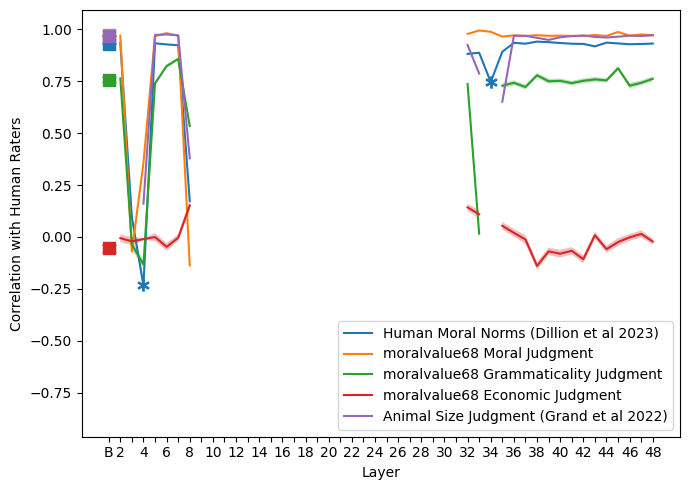

In [19]:
dfs = [
    moral_Dillion_corr_df, 
    moral_moralvalue68_morality_corr_df, 
    moral_moralvalue68_grammar_corr_df, 
    moral_moralvalue68_economic_corr_df,
    moral_size_corr_df, 
    # moral_names_age_corr_df,
    # moral_states_temperature_corr_df,
    # moral_weather_wetness_corr_df,
    ]

labels = [
    'Human Moral Norms (Dillion et al 2023)', 
    'moralvalue68 Moral Judgment', 
    'moralvalue68 Grammaticality Judgment', 
    'moralvalue68 Economic Judgment',
    'Animal Size Judgment (Grand et al 2022)', 
    # 'Name Age Judgment (Grand et al 2022)',
    # 'State Temperature Judgment (Grand et al 2022)',
    # 'Weather Wetness Judgment (Grand et al 2022)',
    ]

plot_correlations(
    dfs, 
    labels, 
    file_name = f'./figures/{model}/2.0_ablate_intervention_with_morality_vector.eps',
    offset = False, 
    stats = stats
    )

### Plot 1-layer intervention using economic vectors

In [ ]:
file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_Dillion/data")
grammar_Dillion_valid_df, grammar_Dillion_corr_df, grammar_Dillion_score_df = load_multiple_files(file_path, 'Dillion', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_moralvalue68_morality/data")
grammar_moralvalue68_morality_valid_df, grammar_moralvalue68_morality_corr_df, grammar_moralvalue68_morality_score_df = load_multiple_files(file_path, 'moralvalue68_morality', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_moralvalue68_grammar/data")
grammar_moralvalue68_grammar_valid_df, grammar_moralvalue68_grammar_corr_df, grammar_moralvalue68_grammar_score_df = load_multiple_files(file_path, 'moralvalue68_grammar', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_animals_size/data")
grammar_size_valid_df,grammar_size_corr_df, grammar_size_score_df = load_multiple_files(file_path, 'animals_size', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_names_age/data")
grammar_names_age_valid_df, grammar_names_age_corr_df, grammar_names_age_score_df = load_multiple_files(file_path, 'names_age', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_states_temperature/data")
grammar_states_temperature_valid_df, grammar_states_temperature_corr_df, grammar_states_temperature_score_df = load_multiple_files(file_path, 'states_temperature', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_grammar_weather_wetness/data")
grammar_weather_wetness_valid_df, grammar_weather_wetness_corr_df, grammar_weather_wetness_score_df = load_multiple_files(file_path, 'weather_wetness', layer, subsample)

In [ ]:
stats = None

if len(file_path) > 1:
    stats = {
        'Human Moral Norms (Dillion et al 2023)': run_layer_permutation_tests(grammar_Dillion_corr_df, grammar_size_corr_df, grammar_states_temperature_corr_df),
        'moralvalue68 Moral Judgment': run_layer_permutation_tests(grammar_moralvalue68_morality_corr_df, grammar_size_corr_df, grammar_states_temperature_corr_df),
        'moralvalue68 Grammaticality Judgment': run_layer_permutation_tests(grammar_moralvalue68_grammar_corr_df, grammar_size_corr_df, grammar_states_temperature_corr_df),
    }

In [ ]:
dfs = [
    grammar_Dillion_corr_df, 
    grammar_moralvalue68_morality_corr_df, 
    grammar_moralvalue68_grammar_corr_df, 
    grammar_size_corr_df, 
    grammar_names_age_corr_df,
    grammar_states_temperature_corr_df,
    grammar_weather_wetness_corr_df,
    ]

labels = [
    'Human Moral Norms (Dillion et al 2023)', 
    'MoralValue68 Moral Judgment', 
    'MoralValue68 Grammaticality Judgment', 
    'Animal Size Judgment (Grand et al 2022)', 
    'Name Age Judgment (Grand et al 2022)',
    'State Temperature Judgment (Grand et al 2022)',
    'Weather Wetness Judgment (Grand et al 2022)',
    ]

plot_correlations(
    dfs, 
    labels, 
    file_name = f'./figures/{model}/2.0_ablate_intervention_with_grammar_vector.eps',
    offset = False, 
    stats = stats
    )

### Plot 1-layer intervention using grammar vectors

In [ ]:
file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_Dillion/data")
economic_Dillion_valid_df, economic_Dillion_corr_df, economic_Dillion_score_df = load_multiple_files(file_path, 'Dillion', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_moralvalue68_morality/data")
economic_moralvalue68_morality_valid_df, economic_moralvalue68_morality_corr_df, economic_moralvalue68_morality_score_df = load_multiple_files(file_path, 'moralvalue68_morality', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_moralvalue68_economic/data")
economic_moralvalue68_economic_valid_df, economic_moralvalue68_economic_corr_df, economic_moralvalue68_economic_score_df = load_multiple_files(file_path, 'moralvalue68_economic', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_animals_size/data")
economic_size_valid_df,economic_size_corr_df, economic_size_score_df = load_multiple_files(file_path, 'animals_size', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_names_age/data")
economic_names_age_valid_df, economic_names_age_corr_df, economic_names_age_score_df = load_multiple_files(file_path, 'names_age', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_states_temperature/data")
economic_states_temperature_valid_df, economic_states_temperature_corr_df, economic_states_temperature_score_df = load_multiple_files(file_path, 'states_temperature', layer, subsample)

file_path = glob.glob(f"./data/{model}/direction_ablation/*_2.0_economic_weather_wetness/data")
economic_weather_wetness_valid_df, economic_weather_wetness_corr_df, economic_weather_wetness_score_df = load_multiple_files(file_path, 'weather_wetness', layer, subsample)

In [ ]:
stats = None

if len(file_path) > 1:
    stats = {
        'Human Moral Norms (Dillion et al 2023)': run_layer_permutation_tests(economic_Dillion_corr_df, economic_size_corr_df, economic_states_temperature_corr_df),
        'MoralValue68 Moral Judgment': run_layer_permutation_tests(economic_moralvalue68_morality_corr_df, economic_size_corr_df, economic_states_temperature_corr_df),
        'MoralValue68 Grammaticality Judgment': run_layer_permutation_tests(economic_moralvalue68_economic_corr_df, economic_size_corr_df, economic_states_temperature_corr_df),
    }

In [ ]:
dfs = [
    economic_Dillion_corr_df, 
    economic_moralvalue68_morality_corr_df, 
    economic_moralvalue68_economic_corr_df, 
    economic_size_corr_df, 
    economic_names_age_corr_df,
    economic_states_temperature_corr_df,
    economic_weather_wetness_corr_df,
    ]

labels = [
    'Human Moral Norms (Dillion et al 2023)', 
    'MoralValue68 Moral Judgment', 
    'MoralValue68 Economic Judgment', 
    'Animal Size Judgment (Grand et al 2022)', 
    'Name Age Judgment (Grand et al 2022)',
    'State Temperature Judgment (Grand et al 2022)',
    'Weather Wetness Judgment (Grand et al 2022)',
    ]

plot_correlations(
    dfs, 
    labels, 
    file_name = f'./figures/{model}/2.0_ablate_intervention_with_economic_vector.eps',
    offset = False, 
    stats = stats
    )

### Plot control stimuli grid (3 vectors x 3 models)

In [31]:
import io
import warnings
from contextlib import redirect_stdout, redirect_stderr

control_models = [
    ('qwen-2.5-7b-it',                  ['qwen-2.5-7b-it']),
    ('gemma-2-9b-it',                   ['gemma-2-9b-it']),
    ('mistral-small-24b-instruct-2501', ['mistral-small-24b-instruct-2501', 'mistral-small-24b-base-2501', 'Mistral-Small-24B-Base-2501', 'Mistral-Small-24B-Instruct-2501']),
]
control_vectors = ['moral', 'grammar', 'economic']
control_stims = [
    ('animals_size',       ['animals_size', 'size']),
    # ('names_age',          ['names_age']),
    ('states_temperature', ['states_temperature']),
    ('weather_wetness',    ['weather_wetness']),
]
data_roots = [
    './data',
    '../archive/exp7/data'
]
subsample = 34

control_dfs = []
failed = []
for v in control_vectors:
    row_dfs = []
    for canon_model, model_aliases in control_models:
        n_layers = NUM_LAYERS_BY_MODEL[canon_model]
        cell_dfs = []
        for eval_name, stim_aliases in control_stims:
            file_path = []
            for root in data_roots:
                for m_alias in model_aliases:
                    for s_alias in stim_aliases:
                        file_path.extend(glob.glob(f"{root}/{m_alias}/direction_ablation/*_2.0_{v}_{s_alias}/data"))
            file_path = [fp for fp in file_path if glob.glob(f"{fp}/baseline_values_*.json")]
            try:
                with warnings.catch_warnings(), redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
                    warnings.simplefilter("ignore")
                    _, corr_df, _ = load_multiple_files(file_path, eval_name, n_layers, subsample)
                if corr_df.empty:
                    raise ValueError("no data found")
                cell_dfs.append(corr_df)
            except Exception as e:
                failed.append((canon_model, v, eval_name, str(e)))
                cell_dfs.append(None)
        row_dfs.append(cell_dfs)
    control_dfs.append(row_dfs)

if failed:
    print(f"Skipped {len(failed)} combinations:")
    for m, v, s, err in failed:
        print(f"  {m} / {v} / {s}: {err}")
else:
    print("All combinations loaded.")

All combinations loaded.


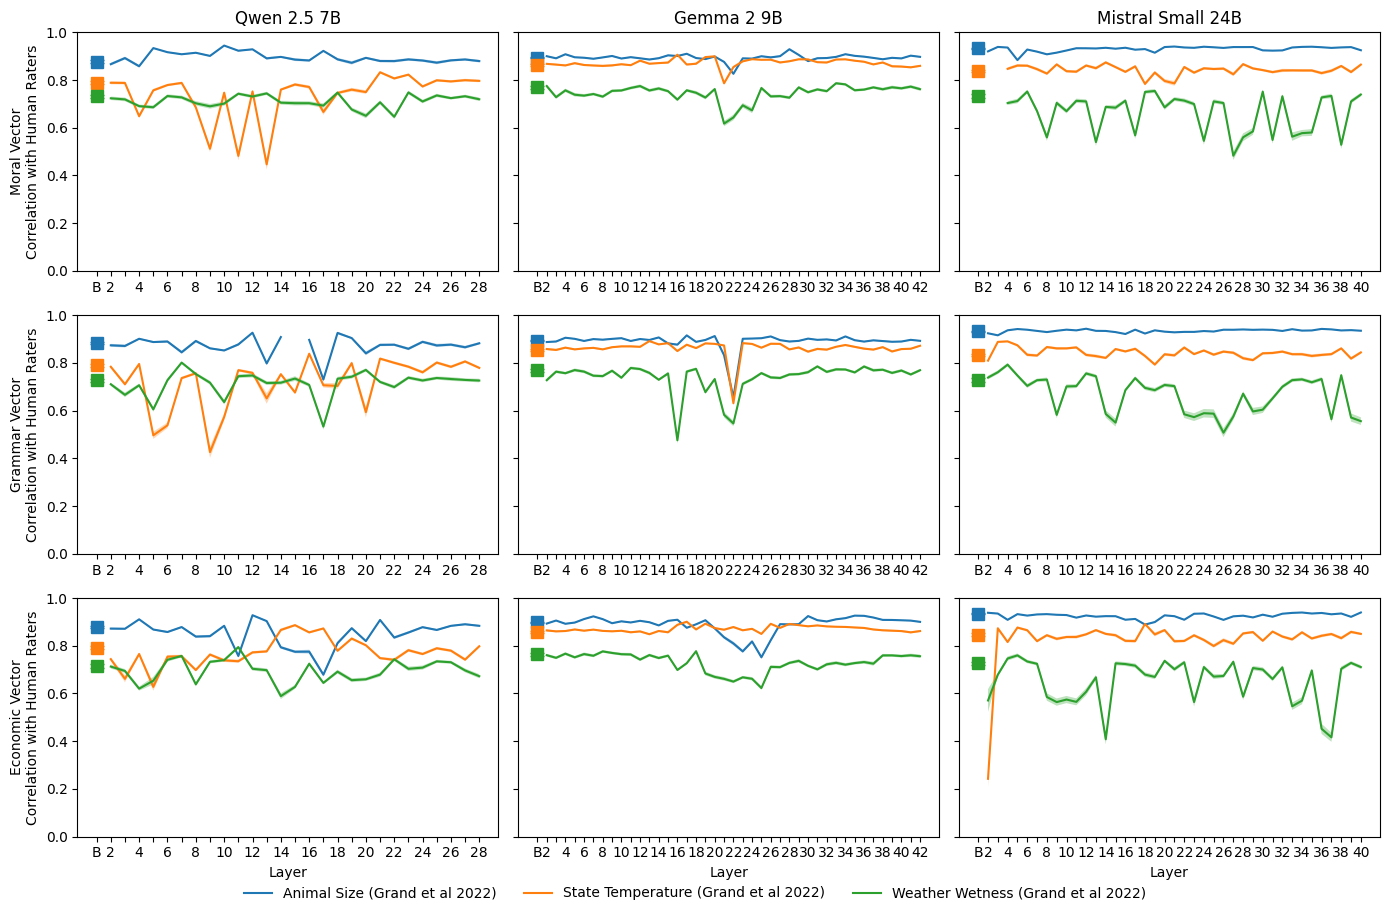

In [32]:
control_labels = [
    'Animal Size (Grand et al 2022)',
    # 'Name Age (Grand et al 2022)',
    'State Temperature (Grand et al 2022)',
    'Weather Wetness (Grand et al 2022)',
]

plot_control_grid(
    control_dfs,
    control_labels,
    offset=False,
    file_name='./figures/control_stimuli_grid.eps',
)